#### Unit Commitment with CPLEX Direct
#### Modular Architecture

## 01. Import Libary
Bagian ini memuat seluruh library yang digunakan untuk:
- pemodelan optimasi UC,
- visualisasi,
- post-processing,
- simulasi frekuensi,
- dan komunikasi solver CPLEX Direct.

In [253]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
# Bagian ini memuat seluruh library yang digunakan dalam model UC,
# post-processing, dan simulasi frekuensi.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyomo.environ import (
    ConcreteModel, Set, Param, Var,
    Constraint, Objective, Expression,
    NonNegativeReals, Binary,
    SolverFactory, minimize, value
)

from pyomo.opt import SolverStatus, TerminationCondition

# =========================================================
# SAFE VALUE READER
# =========================================================

UNINITIALIZED_VARS = []

def get_value(expr, name="", default=0.0, warn=True):

    val = value(expr, exception=False)

    if val is None:

        if warn:
            UNINITIALIZED_VARS.append(name)

        return default

    return val

## Tes CPLEX Direct

In [254]:
# =========================================================
# TEST CPLEX DIRECT
# =========================================================

import cplex
print("CPLEX Version:", cplex.__version__)

from pyomo.environ import SolverFactory

solver_test = SolverFactory("cplex_direct")

print("CPLEX Direct Available:", solver_test.available())

CPLEX Version: 22.1.1.0
CPLEX Direct Available: True


## 02. Konfigurasi Skenario
Bagian ini mengatur:
- solver,
- komponen fungsi objektif,
- aktivasi constraint,
- konfigurasi reserve,
- dan pengaturan simulasi.

Pendekatan modular digunakan agar setiap fitur dapat diaktifkan/nonaktifkan tanpa mengubah struktur model utama.

In [255]:
# ============================================================
# 2. SCENARIO CONFIGURATION
# ============================================================

CONFIG = {
    # Solver
    "solver": "cplex_direct",
    "tee": False,
    "mipgap": 0.001,
    "timelimit": 300,
    
    # Objective components
    "obj_generation_cost": True,
    "obj_fixed_cost": True,
    "obj_startup_cost": True,
    "obj_shutdown_cost": True,
    "obj_reserve_cost": False,
    "obj_curtailment_cost": False,

    # Constraint activation
    "con_power_balance": True,
    "con_capacity_upper": True,
    "con_capacity_lower": True,
    "con_startup_shutdown_logic": True,
    "con_ramp_up": True,
    "con_ramp_down": True,
    "con_minimum_up_time": True,
    "con_minimum_down_time": True,

    "con_n1_spinning_reserve": True,
    "con_dynamic_frequency_security": False,
    "con_steady_primary_frequency": True,

    
    '''
    "con_reserve_headroom": False,
    "con_n1_security": False,
    "con_reserve_ramp_capability": False,
    '''
    
    "con_curtailment_limit": False,
    
    "con_pfr_within_reserve": False,
    "con_pfr_governor_only": False,
    "con_pfr_headroom": False,
    "con_pfr_ramp_capability": False,

    "con_min_inertia": False,
    "con_rocof_limit": False,
    "con_qss_limit": False,
    "con_freq_nadir": False,
    "con_pfr_requirement": False,

    # Reserve settings
    "reserve_response_time": 60/60,
    "pfr_response_time": 10/60,

    # Initial settings
    "use_initial_condition": True,
}

# ============================================================
# PARAMETER FREKUENSI DAN SIMULASI
# ============================================================

f0 = 50.0
f_min = 49.5
df_max = f0 - f_min

D_frac = 0.01
sim_time = 200
dt = 0.02

t_uc = 8

RoCoF_limit = 0.5
f_qss_min = 49.5

3. Read Data Excel

In [256]:
# ============================================================
# 3. READ DATA FROM EXCEL
# ============================================================
# Bagian ini membaca data generator dan demand dari file Excel.

file_path = r"D:\UGM\Tugas Akhir\UC Coding\Belajar\DataSet_ModifikasiCandra_R00.xlsx"

gen_df = pd.read_excel(file_path, sheet_name="Gen")
demand_df = pd.read_excel(file_path, sheet_name="Demand")

# Cek cepat isi data
# print(gen_df.head())
# print(demand_df.head())

4. Validasi Kolom Data

In [257]:
# ============================================================
# 4. DATA VALIDATION
# ============================================================
# Bagian ini memastikan semua kolom wajib tersedia.
# Tujuannya agar error lebih mudah dilacak sebelum masuk ke Pyomo.

required_gen_cols = [
    "Unit", "Pmin", "Pmax", "a", "b", "c",
    "SU_Cost", "SD_Cost",
    "Ramp_Up", "Ramp_Down",
    "Min_Up", "Min_Down",
    "Droop", "PFR_Fraction", "FreeGovernor",
    "Type", "H", "Tg"
]

required_demand_cols = [
    "Hour", "Demand", "Potensi PV (MW)", "Potensi WT (MW)"
]

missing_gen_cols = [col for col in required_gen_cols if col not in gen_df.columns]
missing_demand_cols = [col for col in required_demand_cols if col not in demand_df.columns]

if missing_gen_cols:
    raise ValueError(f"Kolom hilang pada sheet Gen: {missing_gen_cols}")

if missing_demand_cols:
    raise ValueError(f"Kolom hilang pada sheet Demand: {missing_demand_cols}")

5. Konversi DataFrame ke Dictionary

In [258]:
# ============================================================
# 5. CONVERT DATAFRAME TO DICTIONARY
# ============================================================
# Bagian ini mengubah data pandas menjadi dictionary agar mudah
# digunakan sebagai Pyomo Param.

G = gen_df["Unit"].tolist()
T = demand_df["Hour"].tolist()

# Parameter generator
Pmin = dict(zip(gen_df["Unit"], gen_df["Pmin"]))
Pmax = dict(zip(gen_df["Unit"], gen_df["Pmax"]))

PrevUpTime = dict(zip(gen_df["Unit"], gen_df["PrevUpTime"]))
PrevDownTime = dict(zip(gen_df["Unit"], gen_df["PrevDownTime"]))

FreqDeadBand = dict(zip(gen_df["Unit"], gen_df["FreqDeadBand"]))
GovRamp = dict(zip(gen_df["Unit"], gen_df["GovRamp(MW/s)"]))

a = dict(zip(gen_df["Unit"], gen_df["a"]))
b = dict(zip(gen_df["Unit"], gen_df["b"]))
c = dict(zip(gen_df["Unit"], gen_df["c"]))

SU_cost = dict(zip(gen_df["Unit"], gen_df["SU_Cost"]))
SD_cost = dict(zip(gen_df["Unit"], gen_df["SD_Cost"]))

RampUp = dict(zip(gen_df["Unit"], gen_df["Ramp_Up"]))
RampDown = dict(zip(gen_df["Unit"], gen_df["Ramp_Down"]))

MinUp = dict(zip(gen_df["Unit"], gen_df["Min_Up"]))
MinDown = dict(zip(gen_df["Unit"], gen_df["Min_Down"]))

Droop = dict(zip(gen_df["Unit"], gen_df["Droop"]))
PFR_Fraction = dict(zip(gen_df["Unit"], gen_df["PFR_Fraction"]))

PrimRampUp = dict(zip(gen_df["Unit"], gen_df["PrimRampUp"]))

FreeGovernor = dict(zip(gen_df["Unit"], gen_df["FreeGovernor"]))

Type = dict(zip(gen_df["Unit"], gen_df["Type"]))
H = dict(zip(gen_df["Unit"], gen_df["H"]))
Tg = dict(zip(gen_df["Unit"], gen_df["Tg"]))

InitialStatus = dict(zip(gen_df["Unit"], gen_df["InitialStatus"]))
InitialPower  = dict(zip(gen_df["Unit"], gen_df["InitialPower"]))

# Parameter demand
Demand = dict(zip(demand_df["Hour"], demand_df["Demand"]))

PV_Potential = dict(zip(demand_df["Hour"], demand_df["Potensi PV (MW)"]))
WT_Potential = dict(zip(demand_df["Hour"], demand_df["Potensi WT (MW)"]))

6. Parameter Turunan

In [259]:
# ============================================================
# 6. DERIVED PARAMETERS
# ============================================================
# Bagian ini menghitung parameter turunan sebelum masuk model Pyomo.

# Potensi renewable per unit dan waktu
RenewPotential = {}

for g in G:
    for t in T:
        if Type[g] == "PV":
            RenewPotential[g, t] = PV_Potential[t]
        elif Type[g] == "WT":
            RenewPotential[g, t] = WT_Potential[t]
        else:
            RenewPotential[g, t] = Pmax[g]

# Batas maksimum PFR tiap unit
PFR_Max = {
    g: PFR_Fraction[g] * Pmax[g]
    for g in G
}

# Frequency bias tiap generator
# Satuan: MW/Hz
FreqBias = {}

for g in G:
    if Droop[g] > 0 and FreeGovernor[g] == 1:
        FreqBias[g] = Pmax[g] / (Droop[g] * f0)
    else:
        FreqBias[g] = 0

# Biaya reserve sederhana
ReserveCost = {
    g: 0.10 * b[g]
    for g in G
}

7. Definisi Model dan Set

In [260]:
# ============================================================
# 7. MODEL AND SETS
# ============================================================
# Bagian ini membuat model Pyomo dan mendefinisikan set generator serta waktu.

model = ConcreteModel()

model.G = Set(initialize=G)
model.T = Set(initialize=T)

8. Parameter Pyomo

In [261]:
# ============================================================
# 8. PYOMO PARAMETERS
# ============================================================
# Bagian ini memasukkan parameter numerik ke dalam model Pyomo.

model.Pmin = Param(model.G, initialize=Pmin)
model.Pmax = Param(model.G, initialize=Pmax)

model.a = Param(model.G, initialize=a)
model.b = Param(model.G, initialize=b)
model.c = Param(model.G, initialize=c)

model.SU_cost = Param(model.G, initialize=SU_cost)
model.SD_cost = Param(model.G, initialize=SD_cost)

model.RampUp = Param(model.G, initialize=RampUp)
model.RampDown = Param(model.G, initialize=RampDown)

model.MinUp = Param(model.G, initialize=MinUp)
model.MinDown = Param(model.G, initialize=MinDown)

model.PrevUpTime = Param(model.G, initialize=PrevUpTime)
model.PrevDownTime = Param(model.G, initialize=PrevDownTime)

model.Demand = Param(model.T, initialize=Demand)

model.Droop = Param(model.G, initialize=Droop, within=NonNegativeReals)
model.PFR_Fraction = Param(model.G, initialize=PFR_Fraction, within=NonNegativeReals)
model.FreeGovernor = Param(model.G, initialize=FreeGovernor, within=Binary)
model.PFR_Max = Param(model.G, initialize=PFR_Max, within=NonNegativeReals)

model.PrimRampUp = Param(model.G, initialize=PrimRampUp, within=NonNegativeReals)

model.FreqBias = Param(model.G, initialize=FreqBias)
model.ReserveCost = Param(model.G, initialize=ReserveCost)

model.RenewPotential = Param(model.G, model.T, initialize=RenewPotential, within=NonNegativeReals)

model.H = Param(model.G, initialize=H)
model.Tg = Param(model.G, initialize=Tg)

model.InitialStatus = Param(model.G, initialize=InitialStatus)
model.InitialPower  = Param(model.G, initialize=InitialPower)

model.FreqDeadBand = Param(model.G, initialize=FreqDeadBand, within=NonNegativeReals)
model.GovRamp = Param(model.G, initialize=GovRamp, within=NonNegativeReals)

9. Variabel Keputusan UC

In [262]:
# ============================================================
# 9. DECISION VARIABLES
# ============================================================
# Bagian ini mendefinisikan variabel keputusan model UC.
# Semua variabel di sini memengaruhi hasil optimasi.

model.P = Var(model.G, model.T, domain=NonNegativeReals)       # output daya unit
model.u = Var(model.G, model.T, domain=Binary)                 # status ON/OFF unit
model.y = Var(model.G, model.T, domain=Binary)                 # startup
model.z = Var(model.G, model.T, domain=Binary)                 # shutdown

model.R = Var(model.G, model.T, within=NonNegativeReals)       # spinning reserve
model.Curt = Var(model.G, model.T, within=NonNegativeReals)    # renewable curtailment

# R_pfr hanya digunakan jika skenario PFR aktif.
model.R_pfr = Var(model.G, model.T, within=NonNegativeReals)   # primary frequency reserve

model.LargestLoss = Var(model.T, within=NonNegativeReals)      # largest online contingency

delta_f_ss_min = f_qss_min - f0

model.DFt = Var(model.T, bounds=(delta_f_ss_min, 0))
model.DFit = Var(model.G, model.T)
model.PGenHat = Var(model.G, model.T, within=NonNegativeReals)

model.XFlag = Var(model.G, model.T, within=Binary)
model.VFlag = Var(model.G, model.T, within=Binary)

model.SSlack = Var(model.G, model.T, within=NonNegativeReals)
model.HSlack = Var(model.G, model.T, bounds=(delta_f_ss_min, 0))

In [263]:
print(CONFIG)

{'solver': 'cplex_direct', 'tee': False, 'mipgap': 0.001, 'timelimit': 300, 'obj_generation_cost': True, 'obj_fixed_cost': True, 'obj_startup_cost': True, 'obj_shutdown_cost': True, 'obj_reserve_cost': False, 'obj_curtailment_cost': False, 'con_power_balance': True, 'con_capacity_upper': True, 'con_capacity_lower': True, 'con_startup_shutdown_logic': True, 'con_ramp_up': True, 'con_ramp_down': True, 'con_minimum_up_time': True, 'con_minimum_down_time': True, 'con_n1_spinning_reserve': True, 'con_dynamic_frequency_security': False, 'con_steady_primary_frequency': True, '\n    "con_reserve_headroom": False,\n    "con_n1_security": False,\n    "con_reserve_ramp_capability": False,\n    con_curtailment_limit': False, 'con_pfr_within_reserve': False, 'con_pfr_governor_only': False, 'con_pfr_headroom': False, 'con_pfr_ramp_capability': False, 'con_min_inertia': False, 'con_rocof_limit': False, 'con_qss_limit': False, 'con_freq_nadir': False, 'con_pfr_requirement': False, 'reserve_response_ti

## Frequency Security Expressions
12.1 Total System Inertia

12.2 LargestLoss

12.3 TotalPFR

12.4 RoCoF estimate

12.5 QSS frequency estimate

In [264]:
# =========================================================
# 12.1 Total System Inertia
# =========================================================

def hsys_rule(m, t):

    return sum(
        m.H[g] * m.Pmax[g] * m.u[g, t]
        for g in m.G
        if Type[g] not in ["PV", "WT"]
    )

model.Hsys = Expression(
    model.T,
    rule=hsys_rule
)

In [265]:
# =========================================================
# 12.2 Largest Online Contingency
# =========================================================

if hasattr(model, "LargestLossConstraint"):
    model.del_component(model.LargestLossConstraint)

def largest_loss_rule(m, g, t):

    if Type[g] in ["PV", "WT"]:
        return Constraint.Skip

    return m.LargestLoss[t] >= m.P[g, t]

model.LargestLossConstraint = Constraint(
    model.G,
    model.T,
    rule=largest_loss_rule
)

In [266]:
# =========================================================
# 12.3 Total Primary Frequency Response
# =========================================================

def total_pfr_rule(m, t):

    return sum(
        m.R[g, t]        
        for g in m.G
        if Type[g] not in ["PV", "WT"]
    )

model.TotalPFR = Expression(
    model.T,
    rule=total_pfr_rule
)

In [267]:
# =========================================================
# 12.4 RoCoF Estimate
# =========================================================

def rocof_est_rule(m, t):

    return m.LargestLoss[t] * f0 / (2 * m.Hsys[t])

model.RoCoF_est = Expression(
    model.T,
    rule=rocof_est_rule
)

In [268]:
# =========================================================
# 12.5 QSS Frequency Estimate
# =========================================================

def qss_freq_rule(m, t):

    return f0 - (
        m.LargestLoss[t]
        /
        (
            m.TotalPFR[t]
            + D_frac * model.Demand[t]
        )
    )

model.f_qss = Expression(
    model.T,
    rule=qss_freq_rule
)

## 10. Objective Function
Fungsi objektif dibuat modular sehingga setiap komponen biaya dapat diaktifkan atau dinonaktifkan melalui dictionary `CONFIG`.

Komponen biaya yang tersedia:
- biaya pembangkitan,
- biaya fixed/no-load,
- startup cost,
- shutdown cost,
- reserve cost,
- dan biaya lain yang dapat ditambahkan pada tahap berikutnya.

In [269]:
# ============================================================
# 10. OBJECTIVE FUNCTION
# ============================================================

def obj_rule(m):

    total_cost = 0

    # ========================================================
    # Generation Cost
    # ========================================================
    if CONFIG["obj_generation_cost"]:

        total_cost += sum(
            m.b[g] * m.P[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Fixed / No-load Cost
    # ========================================================
    if CONFIG["obj_fixed_cost"]:

        total_cost += sum(
            m.c[g] * m.u[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Startup Cost
    # ========================================================
    if CONFIG["obj_startup_cost"]:

        total_cost += sum(
            m.SU_cost[g] * m.y[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Shutdown Cost
    # ========================================================
    if CONFIG["obj_shutdown_cost"]:

        total_cost += sum(
            m.SD_cost[g] * m.z[g, t]
            for g in m.G
            for t in m.T
        )

    # ========================================================
    # Reserve Cost
    # ========================================================
    if CONFIG["obj_reserve_cost"]:

        total_cost += sum(
            m.ReserveCost[g] * m.R[g, t]
            for g in m.G
            for t in m.T
        )

    return total_cost

# Hapus objective lama jika cell dijalankan ulang
if hasattr(model, "Obj"):
    model.del_component(model.Obj)

model.Obj = Objective(
    rule=obj_rule,
    sense=minimize
)

## 11. Constraint UC Dasar
Bagian ini berisi constraint utama Unit Commitment.

In [270]:
# ----------------------------
# 11.1 Power Balance
# ----------------------------
# Total pembangkitan harus sama dengan demand setiap jam.

if hasattr(model, "Balance"):
    model.del_component(model.Balance)

if CONFIG["con_power_balance"]:

    def balance_rule(m, t):
        return sum(m.P[g, t] for g in m.G) == m.Demand[t]

    model.Balance = Constraint(model.T, rule=balance_rule)

In [271]:
# ----------------------------
# 11.2 Capacity Upper Bound
# ----------------------------
# Output unit tidak boleh melebihi kapasitas maksimum saat unit ON.
# Untuk PV dan WT, batasnya mengikuti potensi renewable.

if hasattr(model, "MaxCap"):
    model.del_component(model.MaxCap)
    
if CONFIG["con_capacity_upper"]:

    def max_rule(m, g, t):
        if Type[g] in ["PV", "WT"]:
            return m.P[g, t] <= m.RenewPotential[g, t]
        else:
            return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

    model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

In [272]:
# ----------------------------
# 11.3 Capacity Lower Bound
# ----------------------------
# Output thermal unit minimal Pmin saat unit ON.
# PV dan WT tidak dipaksa memiliki Pmin.

if hasattr(model, "MinCap"):
    model.del_component(model.MinCap)
    
if CONFIG["con_capacity_lower"]:

    def min_rule(m, g, t):
        if Type[g] in ["PV", "WT"]:
            return m.P[g, t] >= 0
        else:
            return m.P[g, t] >= m.Pmin[g] * m.u[g, t]

    model.MinCap = Constraint(model.G, model.T, rule=min_rule)

In [273]:
# ------------------------------
# 11.4 Startup and Shutdown Transition
# ------------------------------
# Menghubungkan perubahan status unit dengan startup dan shutdown.

if hasattr(model, "StartupShutdown"):
    model.del_component(model.StartupShutdown)

if CONFIG["con_startup_shutdown_logic"]:

    def startup_shutdown_rule(m, g, t):

        if t == m.T.first():

            if not CONFIG["use_initial_condition"]:
                return m.y[g, t] - m.z[g, t] == m.u[g, t]
            
            return m.y[g, t] - m.z[g, t] == m.u[g, t] - m.InitialStatus[g]

        else:
            return m.y[g, t] - m.z[g, t] == m.u[g, t] - m.u[g, t-1]

    model.Transition = Constraint(model.G, model.T, rule=startup_shutdown_rule)

In [274]:
# ------------------------------
# 11.4b Startup and Shutdown Non-Simultaneous
# ------------------------------
# Mencegah startup dan shutdown terjadi bersamaan pada unit dan jam yang sama.

if hasattr(model, "TransitionNonSimultaneous"):
    model.del_component(model.TransitionNonSimultaneous)

if CONFIG["con_startup_shutdown_logic"]:

    def startup_shutdown_non_simultaneous_rule(m, g, t):
        return m.y[g, t] + m.z[g, t] <= 1

    model.TransitionNonSimultaneous = Constraint(
        model.G,
        model.T,
        rule=startup_shutdown_non_simultaneous_rule
    )

In [275]:
# ----------------------------
# 11.5 Ramp Up
# ----------------------------
# Membatasi kenaikan daya antar jam.

if hasattr(model, "RampUpConstraint"):
    model.del_component(model.RampUpConstraint)

if CONFIG["con_ramp_up"]:

    def ramp_up_rule(m, g, t):

        # -------------------------------------------------
        # Startup/shutdown ramp allowance
        # -------------------------------------------------
        startup_ramp_allowance = max(
            value(m.Pmin[g]) - value(m.RampUp[g]),
            0
        )

        shutdown_ramp_allowance = max(
            value(m.Pmin[g]) - value(m.RampDown[g]),
            0
        )

        # -------------------------------------------------
        # First hour
        # -------------------------------------------------
        if t == m.T.first():

            if not CONFIG["use_initial_condition"]:
                return Constraint.Skip

            return (
                m.P[g, t]
                + shutdown_ramp_allowance * m.z[g, t]
                - startup_ramp_allowance * m.y[g, t]
                <= m.RampUp[g] + m.InitialPower[g]
            )

        # -------------------------------------------------
        # Normal hour
        # -------------------------------------------------
        return (
            m.P[g, t]
            - m.P[g, t-1]
            + shutdown_ramp_allowance * m.z[g, t]
            - startup_ramp_allowance * m.y[g, t]
            <= m.RampUp[g]
        )

    model.RampUpConstraint = Constraint(
        model.G,
        model.T,
        rule=ramp_up_rule
    )

In [276]:
# ----------------------------
# 11.6 Ramp Down
# ----------------------------
# Membatasi penurunan daya antar jam.

if hasattr(model, "RampDownConstraint"):
    model.del_component(model.RampDownConstraint)

if CONFIG["con_ramp_down"]:

    def ramp_down_rule(m, g, t):

        # -------------------------------------------------
        # Startup/shutdown ramp allowance
        # -------------------------------------------------
        startup_ramp_allowance = max(
            value(m.Pmin[g]) - value(m.RampUp[g]),
            0
        )

        shutdown_ramp_allowance = max(
            value(m.Pmin[g]) - value(m.RampDown[g]),
            0
        )

        # -------------------------------------------------
        # First hour
        # -------------------------------------------------
        if t == m.T.first():

            if not CONFIG["use_initial_condition"]:
                return Constraint.Skip

            return (
                m.InitialPower[g]
                - m.P[g, t]
                - shutdown_ramp_allowance * m.z[g, t]
                + startup_ramp_allowance * m.y[g, t]
                <= m.RampDown[g]
            )

        # -------------------------------------------------
        # Normal hour
        # -------------------------------------------------
        return (
            m.P[g, t-1]
            - m.P[g, t]
            - shutdown_ramp_allowance * m.z[g, t]
            + startup_ramp_allowance * m.y[g, t]
            <= m.RampDown[g]
        )

    model.RampDownConstraint = Constraint(
        model.G,
        model.T,
        rule=ramp_down_rule
    )

In [277]:
# ============================================================
# Minimum Up Time - backward-looking ala myUC
# ============================================================

if hasattr(model, "MinUpTime"):
    model.del_component(model.MinUpTime)

if CONFIG["con_minimum_up_time"]:

    T_LIST = sorted(list(model.T))
    T_POS = {t: i for i, t in enumerate(T_LIST)}

    def min_up_time_rule(m, g, t):

        MUT = int(value(m.MinUp[g]))
        k = T_POS[t]

        if MUT <= 0:
            return Constraint.Skip

        # awal horizon
        if k < MUT:

            prev_hours = T_LIST[:k]

            return (
                -sum(m.u[g, h] for h in prev_hours)
                + MUT * m.z[g, t]
                <= m.PrevUpTime[g]
            )

        # normal
        else:

            prev_hours = T_LIST[k-MUT:k]

            return (
                -sum(m.u[g, h] for h in prev_hours)
                + MUT * m.z[g, t]
                <= 0
            )

    model.MinUpTime = Constraint(
        model.G,
        model.T,
        rule=min_up_time_rule
    )

In [278]:
# ============================================================
# Minimum Down Time - backward-looking ala myUC
# ============================================================

if hasattr(model, "MinDownTime"):
    model.del_component(model.MinDownTime)

if CONFIG["con_minimum_down_time"]:

    T_LIST = sorted(list(model.T))
    T_POS = {t: i for i, t in enumerate(T_LIST)}

    def min_down_time_rule(m, g, t):

        MDT = int(value(m.MinDown[g]))
        k = T_POS[t]

        if MDT <= 0:
            return Constraint.Skip

        # awal horizon
        if k < MDT:

            prev_hours = T_LIST[:k]

            return (
                sum(m.u[g, h] for h in prev_hours)
                + MDT * m.y[g, t]
                <= k + m.PrevDownTime[g]
            )

        # normal
        else:

            prev_hours = T_LIST[k-MDT:k]

            return (
                sum(m.u[g, h] for h in prev_hours)
                + MDT * m.y[g, t]
                <= MDT
            )

    model.MinDownTime = Constraint(
        model.G,
        model.T,
        rule=min_down_time_rule
    )

## 12. Contraint Reserve
Bagian ini mengatur reserve

In [279]:
# =========================================================
# N-1 Spinning Reserve Security
# =========================================================

for comp in [
    "ReserveHeadroom",
    "N1SpinningReserve"
]:
    if hasattr(model, comp):
        model.del_component(getattr(model, comp))


if CONFIG["con_n1_spinning_reserve"]:

    # -----------------------------------------------------
    # 1. Reserve Headroom
    # P[g,t] + R[g,t] <= Pmax[g] * u[g,t]
    # -----------------------------------------------------

    def reserve_headroom_rule(m, g, t):

        if Type[g] in ["PV", "WT"]:
            return m.R[g, t] == 0

        return (
            m.P[g, t] + m.R[g, t]
            <= m.Pmax[g] * m.u[g, t]
        )

    model.ReserveHeadroom = Constraint(
        model.G,
        model.T,
        rule=reserve_headroom_rule
    )


    # -----------------------------------------------------
    # 2. N-1 Spinning Reserve
    # sum R[k,t], k != outage_g >= P[outage_g,t]
    # -----------------------------------------------------

    def n1_spinning_reserve_rule(m, outage_g, t):

        if Type[outage_g] in ["PV", "WT"]:
            return Constraint.Skip

        return (
            sum(
                m.R[g, t]
                for g in m.G
                if g != outage_g and Type[g] not in ["PV", "WT"]
            )
            >=
            m.P[outage_g, t]
        )

    model.N1SpinningReserve = Constraint(
        model.G,
        model.T,
        rule=n1_spinning_reserve_rule
    )

In [280]:
# =========================================================
# Dynamic Frequency Security Constraint
# Equivalent concept to myUC consWorstCaseInertia
# =========================================================

if hasattr(model, "DynamicFrequencySecurity"):
    model.del_component(model.DynamicFrequencySecurity)

if CONFIG["con_dynamic_frequency_security"]:

    thermal_units = [
        g for g in model.G
        if Type[g] not in ["PV", "WT"]
    ]

    P_loss = max(Pmax[g] for g in thermal_units)

    g_loss = max(
        thermal_units,
        key=lambda g: Pmax[g]
    )

    f_nominal = f0
    freq_deviation_max = f0 - f_min
    f_nadir = f_min

    def dynamic_frequency_security_rule(m, g, t):

        if Type[g] in ["PV", "WT"]:
            return Constraint.Skip

        denominator = (
            m.GovRamp[g]
            * (
                4 * f_nominal
                - 2 * m.FreqDeadBand[g]
                - 4 * f_nadir
            )
        )

        alpha = f_nominal * P_loss / denominator

        return (
            alpha * m.R[g, t]
            - sum(
                m.H[k] * m.Pmax[k] * m.u[k, t]
                for k in thermal_units
            )
            <=
            - m.H[g_loss] * P_loss
        )

    model.DynamicFrequencySecurity = Constraint(
        model.G,
        model.T,
        rule=dynamic_frequency_security_rule
    )

In [281]:
# =========================================================
# Steady Primary Frequency Constraint
# Equivalent to myUC consSteadyPrimFreq
# =========================================================

if CONFIG["con_steady_primary_frequency"]:

    # -----------------------------------------------------
    # 1. Primary reserve + P <= Pmax * u
    # myUC: PGen + RPr <= Pmax * UC
    # -----------------------------------------------------
    def steady_rpr_headroom_rule(m, g, t):
        return m.P[g, t] + m.R_pfr[g, t] <= m.Pmax[g] * m.u[g, t]

    model.Steady_RPr_Headroom = Constraint(model.G, model.T, rule=steady_rpr_headroom_rule)


    # -----------------------------------------------------
    # 2. RPr <= PrimRampUp * u
    # myUC: RPr <= RPMAX * UC
    # -----------------------------------------------------
    def steady_rpr_status_rule(m, g, t):
        return m.R_pfr[g, t] <= m.PrimRampUp[g] * m.u[g, t]

    model.Steady_RPr_Status = Constraint(model.G, model.T, rule=steady_rpr_status_rule)


    # -----------------------------------------------------
    # 3. Primary reserve must cover every outage unit
    # myUC: P_g <= sum RPr_k, k != g
    # -----------------------------------------------------
    def steady_rpr_outage_rule(m, g, t):
        return m.P[g, t] <= sum(
            m.R_pfr[k, t]
            for k in m.G
            if k != g
        )

    model.Steady_RPr_Outage = Constraint(model.G, model.T, rule=steady_rpr_outage_rule)


    # -----------------------------------------------------
    # 4. DFit
    # myUC: (1/droop)*P - DFit - (1/droop)*PGenHat = 0
    # -----------------------------------------------------
    def steady_dfit_rule(m, g, t):
        return m.DFit[g, t] == (
            m.P[g, t] - m.PGenHat[g, t]
        ) / m.FreqBias[g]

    model.Steady_DFit = Constraint(model.G, model.T, rule=steady_dfit_rule)


    # -----------------------------------------------------
    # 5. DFt lower bound
    # myUC: DFt >= deltaFreqMin
    # -----------------------------------------------------
    def steady_dft_limit_rule(m, t):
        return m.DFt[t] >= delta_f_ss_min

    model.Steady_DFt_Limit = Constraint(model.T, rule=steady_dft_limit_rule)


    # -----------------------------------------------------
    # 6. VFlag
    # myUC eq 16
    # -----------------------------------------------------
    def steady_vflag_1_rule(m, g, t):
        return (
            (1 - m.PrimRampUp[g] / m.Pmax[g]) * m.u[g, t]
            - (1 / m.Pmax[g]) * m.P[g, t]
            - m.VFlag[g, t]
            <= 0
        )

    model.Steady_VFlag_1 = Constraint(model.G, model.T, rule=steady_vflag_1_rule)


    def steady_vflag_2_rule(m, g, t):
        return (
            (-2 + m.PrimRampUp[g] / m.Pmax[g]) * m.u[g, t]
            + (1 / m.Pmax[g]) * m.P[g, t]
            + m.VFlag[g, t]
            <= 0
        )

    model.Steady_VFlag_2 = Constraint(model.G, model.T, rule=steady_vflag_2_rule)


    # -----------------------------------------------------
    # 7. PGenHat
    # myUC eq 18
    # -----------------------------------------------------
    def steady_pgenhat_rule(m, g, t):
        return (
            m.Pmax[g] * m.u[g, t]
            - m.PGenHat[g, t]
            + (m.PrimRampUp[g] - m.Pmax[g]) * m.VFlag[g, t]
            + m.SSlack[g, t]
            == 0
        )

    model.Steady_PGenHat = Constraint(model.G, model.T, rule=steady_pgenhat_rule)


    # -----------------------------------------------------
    # 8. SSlack = VFlag * P
    # myUC eq 19
    # -----------------------------------------------------
    def steady_sslack_1_rule(m, g, t):
        return m.Pmin[g] * m.VFlag[g, t] - m.SSlack[g, t] <= 0

    model.Steady_SSlack_1 = Constraint(model.G, model.T, rule=steady_sslack_1_rule)


    def steady_sslack_2_rule(m, g, t):
        return -m.Pmax[g] * m.VFlag[g, t] + m.SSlack[g, t] <= 0

    model.Steady_SSlack_2 = Constraint(model.G, model.T, rule=steady_sslack_2_rule)


    def steady_sslack_3_rule(m, g, t):
        return -m.P[g, t] + m.SSlack[g, t] <= 0

    model.Steady_SSlack_3 = Constraint(model.G, model.T, rule=steady_sslack_3_rule)


    def steady_sslack_4_rule(m, g, t):
        return m.P[g, t] + m.Pmax[g] * m.VFlag[g, t] - m.SSlack[g, t] <= m.Pmax[g]

    model.Steady_SSlack_4 = Constraint(model.G, model.T, rule=steady_sslack_4_rule)


    # -----------------------------------------------------
    # 9. XFlag
    # myUC eq 21
    # -----------------------------------------------------
    def steady_xflag_1_rule(m, g, t):
        return (
            (-1 / m.PrimRampUp[g]) * m.DFt[t]
            + (1 / m.PrimRampUp[g]) * m.DFit[g, t]
            - m.XFlag[g, t]
            <= 0
        )

    model.Steady_XFlag_1 = Constraint(model.G, model.T, rule=steady_xflag_1_rule)


    def steady_xflag_2_rule(m, g, t):
        return (
            (1 / m.PrimRampUp[g]) * m.DFt[t]
            - (1 / m.PrimRampUp[g]) * m.DFit[g, t]
            + m.XFlag[g, t]
            <= 1
        )

    model.Steady_XFlag_2 = Constraint(model.G, model.T, rule=steady_xflag_2_rule)


    # -----------------------------------------------------
    # 10. XFlag2
    # myUC eq 22
    # -----------------------------------------------------
    def steady_xflag2_1_rule(m, g, t):
        return (
            -m.R_pfr[g, t]
            - m.Pmax[g] * m.XFlag[g, t]
            - m.FreqBias[g] * m.HSlack[g, t]
            <= 0
        )

    model.Steady_XFlag2_1 = Constraint(model.G, model.T, rule=steady_xflag2_1_rule)


    def steady_xflag2_2_rule(m, g, t):
        return m.R_pfr[g, t] + m.FreqBias[g] * m.HSlack[g, t] <= 0

    model.Steady_XFlag2_2 = Constraint(model.G, model.T, rule=steady_xflag2_2_rule)


    # -----------------------------------------------------
    # 11. XFlag3
    # myUC eq 23
    # -----------------------------------------------------
    def steady_xflag3_1_rule(m, g, t):
        return (
            -m.R_pfr[g, t]
            - m.FreqBias[g] * m.DFit[g, t]
            + m.Pmax[g] * m.XFlag[g, t]
            <= m.Pmax[g]
        )

    model.Steady_XFlag3_1 = Constraint(model.G, model.T, rule=steady_xflag3_1_rule)


    def steady_xflag3_2_rule(m, g, t):
        return m.R_pfr[g, t] + m.FreqBias[g] * m.DFit[g, t] <= 0

    model.Steady_XFlag3_2 = Constraint(model.G, model.T, rule=steady_xflag3_2_rule)


    # -----------------------------------------------------
    # 12. HSlack = u * DFt
    # myUC eq 24
    # -----------------------------------------------------
    def steady_hslack_1_rule(m, g, t):
        return delta_f_ss_min * m.u[g, t] - m.HSlack[g, t] <= 0

    model.Steady_HSlack_1 = Constraint(model.G, model.T, rule=steady_hslack_1_rule)


    def steady_hslack_2_rule(m, g, t):
        return (
            -delta_f_ss_min * m.u[g, t]
            - m.DFt[t]
            + m.HSlack[g, t]
            <= -delta_f_ss_min
        )

    model.Steady_HSlack_2 = Constraint(model.G, model.T, rule=steady_hslack_2_rule)


    def steady_hslack_3_rule(m, g, t):
        return m.DFt[t] - m.HSlack[g, t] <= 0

    model.Steady_HSlack_3 = Constraint(model.G, model.T, rule=steady_hslack_3_rule)

In [282]:
# ----------------------------
# 12.1 Reserve Headroom
# ----------------------------
# Reserve hanya boleh berasal dari kapasitas kosong unit thermal.
# PV dan WT tidak menyediakan spinning reserve dalam model ini.
'''
if hasattr(model, "ReserveHeadroom"):
    model.del_component(model.ReserveHeadroom)

if CONFIG["con_reserve_headroom"]:

    def reserve_headroom_rule(m, g, t):

        return (
            m.P[g, t] + m.R[g, t]
            <= m.Pmax[g] * m.u[g, t]
        )

    model.ReserveHeadroom = Constraint(model.G, model.T, rule=reserve_headroom_rule)
'''

'\nif hasattr(model, "ReserveHeadroom"):\n    model.del_component(model.ReserveHeadroom)\n\nif CONFIG["con_reserve_headroom"]:\n\n    def reserve_headroom_rule(m, g, t):\n\n        return (\n            m.P[g, t] + m.R[g, t]\n            <= m.Pmax[g] * m.u[g, t]\n        )\n\n    model.ReserveHeadroom = Constraint(model.G, model.T, rule=reserve_headroom_rule)\n'

In [283]:
# ----------------------------
# 12.2 N-1 Reserve Constraint
# ----------------------------
# Reserve dari unit lain harus cukup untuk menutup kehilangan unit thermal terbesar.
# Constraint ini membuat model lebih aman terhadap kontingensi unit terbesar.
'''
if hasattr(model, "N1Reserve"):
    model.del_component(model.N1Reserve)

if CONFIG["con_n1_security"]:

    def n1_reserve_rule(m, outage_g, t):

        if Type[outage_g] not in ["PV", "WT"]:
            return sum(
                m.R[g, t]
                for g in m.G
                if g != outage_g and Type[g] not in ["PV", "WT"]
            ) >= m.P[outage_g, t]
        else:
            return Constraint.Skip

    model.N1Reserve = Constraint(model.G, model.T, rule=n1_reserve_rule)
'''

'\nif hasattr(model, "N1Reserve"):\n    model.del_component(model.N1Reserve)\n\nif CONFIG["con_n1_security"]:\n\n    def n1_reserve_rule(m, outage_g, t):\n\n        if Type[outage_g] not in ["PV", "WT"]:\n            return sum(\n                m.R[g, t]\n                for g in m.G\n                if g != outage_g and Type[g] not in ["PV", "WT"]\n            ) >= m.P[outage_g, t]\n        else:\n            return Constraint.Skip\n\n    model.N1Reserve = Constraint(model.G, model.T, rule=n1_reserve_rule)\n'

In [284]:
# ----------------------------
# 12.3 Reserve Ramp Capability
# ----------------------------
# Reserve tidak boleh melebihi kemampuan ramp-up unit.
'''
if hasattr(model, "ReserveRampCapability"):
    model.del_component(model.ReserveRampCapability)

if CONFIG["con_reserve_ramp_capability"]:

    def reserve_ramp_capability_rule(m, g, t):
        return m.R[g, t] <= m.RampUp[g] * CONFIG["reserve_response_time"]

    model.ReserveRampCapability = Constraint(
        model.G,
        model.T,
        rule=reserve_ramp_capability_rule
    )
'''

'\nif hasattr(model, "ReserveRampCapability"):\n    model.del_component(model.ReserveRampCapability)\n\nif CONFIG["con_reserve_ramp_capability"]:\n\n    def reserve_ramp_capability_rule(m, g, t):\n        return m.R[g, t] <= m.RampUp[g] * CONFIG["reserve_response_time"]\n\n    model.ReserveRampCapability = Constraint(\n        model.G,\n        model.T,\n        rule=reserve_ramp_capability_rule\n    )\n'

## 13. Renewable & Curtailment
Curtailment = potensi renewable - dispatch renewable.

In [285]:
# ----------------------------.
# 13.1 Renewable Curtailment
# ----------------------------
# Curtailment = potensi renewable - dispatch renewable.
'''
if hasattr(model, "Curtailment"):
    model.del_component(model.Curtailment)

if CONFIG["con_curtailment_limit"]:

    def curtailment_rule(m, g, t):
        if Type[g] in ["PV", "WT"]:
            return m.Curt[g, t] == m.RenewPotential[g, t] - m.P[g, t]
        else:
            return m.Curt[g, t] == 0

    model.Curtailment = Constraint(model.G, model.T, rule=curtailment_rule)
'''

'\nif hasattr(model, "Curtailment"):\n    model.del_component(model.Curtailment)\n\nif CONFIG["con_curtailment_limit"]:\n\n    def curtailment_rule(m, g, t):\n        if Type[g] in ["PV", "WT"]:\n            return m.Curt[g, t] == m.RenewPotential[g, t] - m.P[g, t]\n        else:\n            return m.Curt[g, t] == 0\n\n    model.Curtailment = Constraint(model.G, model.T, rule=curtailment_rule)\n'

## 14. Constraint PFR/FCUC
Bagian ini memodelkan kemampuan sistem dalam menjaga stabilitas frekuensi
setelah terjadi gangguan pembangkit atau ketidakseimbangan daya.

Primary Frequency Response (PFR) disediakan oleh unit pembangkit yang
memiliki governor dan reserve yang cukup untuk merespons deviasi frekuensi.

Constraint pada bagian ini bertujuan untuk:
- memastikan reserve dapat digunakan untuk PFR,
- membatasi partisipasi hanya pada unit dengan governor,
- menjaga kecukupan respons frekuensi sistem,
- dan mendukung studi Frequency-Constrained Unit Commitment (FCUC).

In [286]:
# ----------------------------
# 14.1 PFR Within Reserve
# ----------------------------
# PFR tidak boleh melebihi reserve yang tersedia.

if hasattr(model, "PFRWithinReserve"):
    model.del_component(model.PFRWithinReserve)

if CONFIG["con_pfr_within_reserve"]:

    def pfr_within_reserve_rule(m, g, t):
        return m.R_pfr[g, t] <= m.R[g, t]

    model.PFRWithinReserve = Constraint(
        model.G,
        model.T,
        rule=pfr_within_reserve_rule
    )

In [287]:
# ----------------------------
# 14.2 PFR Governor Capability
# ----------------------------
# Hanya unit dengan free governor yang dapat menyediakan PFR.

if hasattr(model, "PFRGovernorCapability"):
    model.del_component(model.PFRGovernorCapability)

if CONFIG["con_pfr_governor_only"]:

    def pfr_governor_capability_rule(m, g, t):
        return (
            m.R_pfr[g, t]
            <= m.PFR_Max[g] * m.FreeGovernor[g] * m.u[g, t]
        )

    model.PFRGovernorCapability = Constraint(
        model.G,
        model.T,
        rule=pfr_governor_capability_rule
    )

In [288]:
# ----------------------------
# 14.3 PFR Headroom
# ----------------------------
# PFR harus tersedia dari headroom unit.

if hasattr(model, "PFRHeadroom"):
    model.del_component(model.PFRHeadroom)

if CONFIG["con_pfr_headroom"]:

    def pfr_headroom_rule(m, g, t):
        return (
            m.P[g, t] + m.R_pfr[g, t]
            <= m.Pmax[g] * m.u[g, t]
        )

    model.PFRHeadroom = Constraint(
        model.G,
        model.T,
        rule=pfr_headroom_rule
    )

In [289]:
# ----------------------------
# 14.4 PFR Ramp Capability
# ----------------------------
# PFR tidak boleh melebihi kemampuan ramp-up unit
# dalam waktu respons PFR tertentu.

if hasattr(model, "PFRRampCapability"):
    model.del_component(model.PFRRampCapability)

if CONFIG["con_pfr_ramp_capability"]:

    def pfr_ramp_capability_rule(m, g, t):
        return (
            m.R_pfr[g, t]
            <= m.RampUp[g] * CONFIG["pfr_response_time"]
        )

    model.PFRRampCapability = Constraint(
        model.G,
        model.T,
        rule=pfr_ramp_capability_rule
    )

## Constraint Frekuensi

In [290]:
# =========================================================
# Frequency Constraint: RoCoF Limit
# =========================================================

if hasattr(model, "RoCoFLimitConstraint"):
    model.del_component(model.RoCoFLimitConstraint)

if CONFIG["con_rocof_limit"]:

    def rocof_limit_rule(m, t):
        return (
            m.LargestLoss[t] * f0
            <= 2 * RoCoF_limit * m.Hsys[t]
        )

    model.RoCoFLimitConstraint = Constraint(
        model.T,
        rule=rocof_limit_rule
    )

In [291]:
# =========================================================
# Frequency Constraint: QSS Frequency
# =========================================================

if hasattr(model, "QSSLimitConstraint"):
    model.del_component(model.QSSLimitConstraint)

if CONFIG["con_qss_limit"]:

    def qss_limit_rule(m, t):

        damping_term = D_frac * Demand[t]

        return (
            m.LargestLoss[t]
            <=
            (f0 - f_min) *
            (damping_term + m.TotalPFR[t])
        )

    model.QSSLimitConstraint = Constraint(
        model.T,
        rule=qss_limit_rule
    )

14. Solve Model

In [292]:
# ============================================================
# 14. SOLVE MODEL
# ============================================================
# Bagian ini menjalankan solver MILP.

solver = SolverFactory("cplex_direct")
results = solver.solve(model, tee=False)

if (
    results.solver.status == SolverStatus.ok
    and results.solver.termination_condition == TerminationCondition.optimal
):
    print("Optimal solution found.")
else:
    print("Model infeasible or not optimal.")
    print(results.solver.status)
    print(results.solver.termination_condition)

Optimal solution found.


In [293]:
from pyomo.environ import value

print("\n========== CHECK N-1 SPINNING RESERVE ==========")

for t in model.T:
    min_margin = 1e9
    worst_unit = None

    for outage_g in model.G:
        if Type[outage_g] in ["PV", "WT"]:
            continue

        outage = value(model.P[outage_g, t])

        reserve_other = sum(
            value(model.R[g, t])
            for g in model.G
            if g != outage_g and Type[g] not in ["PV", "WT"]
        )

        margin = reserve_other - outage

        if margin < min_margin:
            min_margin = margin
            worst_unit = outage_g

    print(
        f"Hour {t}: Worst outage = {worst_unit}, "
        f"Min margin = {min_margin:.4f}"
    )


========== CHECK N-1 SPINNING RESERVE ==========
Hour 1: Worst outage = G1, Min margin = 1483.3232
Hour 2: Worst outage = G1, Min margin = 1535.8315
Hour 3: Worst outage = G1, Min margin = 1619.7982
Hour 4: Worst outage = G1, Min margin = 1699.6166
Hour 5: Worst outage = G1, Min margin = 1699.6166
Hour 6: Worst outage = G1, Min margin = 1497.4790
Hour 7: Worst outage = G1, Min margin = 1435.9396
Hour 8: Worst outage = G1, Min margin = 1484.3081
Hour 9: Worst outage = G1, Min margin = 1177.5459
Hour 10: Worst outage = G1, Min margin = 861.9281
Hour 11: Worst outage = G1, Min margin = 728.0154
Hour 12: Worst outage = G1, Min margin = 676.8842
Hour 13: Worst outage = G1, Min margin = 927.4154
Hour 14: Worst outage = G1, Min margin = 753.1887
Hour 15: Worst outage = G1, Min margin = 601.5730
Hour 16: Worst outage = G1, Min margin = 646.4109
Hour 17: Worst outage = G1, Min margin = 708.5512
Hour 18: Worst outage = G1, Min margin = 808.4432
Hour 19: Worst outage = G1, Min margin = 756.7277


## Debug Frekuensi

In [294]:
# =========================================================
# MASTER DEBUG FREQUENCY SECURITY
# =========================================================

freq_debug_rows = []

for t in model.T:

    hsys = get_value(model.Hsys[t], f"Hsys[{t}]")
    loss = get_value(model.LargestLoss[t], f"LargestLoss[{t}]")
    pfr  = get_value(model.TotalPFR[t], f"TotalPFR[{t}]")
    rocof = get_value(model.RoCoF_est[t], f"RoCoF_est[{t}]")
    fqss = get_value(model.f_qss[t], f"f_qss[{t}]")

    freq_debug_rows.append({

        "Hour": t,

        # Dynamic quantities
        "Hsys": hsys,
        "LargestLoss": loss,
        "TotalPFR": pfr,

        # Frequency metrics
        "RoCoF": rocof,
        "f_qss": fqss,

        # Security checks
        "RoCoF_OK": abs(rocof) <= RoCoF_limit,
        "f_qss_OK": fqss >= f_min,

    })

df_freq_debug = pd.DataFrame(freq_debug_rows)

display(df_freq_debug)

,Hour,Hsys,LargestLoss,TotalPFR,RoCoF,f_qss,RoCoF_OK,f_qss_OK
0,1,42690.0,1176.0,2659.323165,0.688686,49.564699,False,True
1,2,42690.0,1176.0,2711.831546,0.688686,49.572917,False,True
2,3,42690.0,1056.0,2795.798214,0.618412,49.627735,False,True
3,4,42690.0,936.0,2875.616629,0.548138,49.678980,False,True
4,5,42690.0,966.0,2875.616629,0.565706,49.668691,False,True
5,6,42690.0,1056.0,2673.478977,0.618412,49.611135,False,True
6,7,42690.0,1176.0,2611.939589,0.688686,49.557007,False,True
7,8,42690.0,1056.0,2660.308063,0.618412,49.609259,False,True
8,9,42690.0,1079.0,2353.545939,0.631881,49.550203,False,True
9,10,42690.0,1079.0,2037.928087,0.631881,49.482841,False,False


In [295]:
# =========================================================
# OBJECTIVE COST BREAKDOWN
# =========================================================

generation_cost = sum(
    get_value(model.b[g], f"b[{g}]") * get_value(model.P[g, t], f"P[{g},{t}]")
    for g in model.G for t in model.T
)

fixed_cost = sum(
    get_value(model.c[g], f"c[{g}]") * get_value(model.u[g, t], f"u[{g},{t}]")
    for g in model.G for t in model.T
)

startup_cost = sum(
    get_value(model.SU_cost[g], f"SU_cost[{g}]") * get_value(model.y[g, t], f"y[{g},{t}]")
    for g in model.G for t in model.T
)

shutdown_cost = sum(
    get_value(model.SD_cost[g], f"SD_cost[{g}]") * get_value(model.z[g, t], f"z[{g},{t}]")
    for g in model.G for t in model.T
)

reserve_cost = sum(
    get_value(model.ReserveCost[g], f"ReserveCost[{g}]") * get_value(model.R[g, t], f"R[{g},{t}]")
    for g in model.G for t in model.T
) if CONFIG["obj_reserve_cost"] else 0

total_cost_manual = (
    generation_cost
    + fixed_cost
    + startup_cost
    + shutdown_cost
    + reserve_cost
)

objective_value = get_value(model.Obj, "Objective")

df_cost_breakdown = pd.DataFrame([
    ["Generation Cost", generation_cost],
    ["Fixed Cost", fixed_cost],
    ["Startup Cost", startup_cost],
    ["Shutdown Cost", shutdown_cost],
    ["Reserve Cost", reserve_cost],
    ["Total Cost Manual", total_cost_manual],
    ["Objective Value", objective_value],
], columns=["Cost Component", "Value"])

df_cost_breakdown["Value"] = df_cost_breakdown["Value"].map(
    lambda x: f"{x:,.2f}"
)

df_cost_breakdown

,Cost Component,Value
0,Generation Cost,"3,723,124.64"
1,Fixed Cost,"551,968.11"
2,Startup Cost,0.00
3,Shutdown Cost,0.00
4,Reserve Cost,0.00
5,Total Cost Manual,"4,275,092.74"
6,Objective Value,"4,275,092.74"


15-Build Result DataFrame

In [296]:
# ============================================================
# 15. BUILD RESULT DATAFRAME
# ============================================================
# Bagian ini mengambil hasil optimasi dari Pyomo dan menyusunnya
# menjadi dataframe agar mudah dibaca, dicetak, dan diplot.

def fmt(x):
    if abs(x - round(x)) < 1e-6:
        return int(round(x))
    return round(x, 2)


rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand": fmt(value(model.Demand[t]))
    }

    total_power = 0
    total_reserve = 0
    total_pfr = 0

    fuel_cost = 0
    fixed_cost = 0
    startup_cost = 0
    shutdown_cost = 0
    reserve_cost = 0

    for g in model.G:
        p = get_value(model.P[g, t], f"P[{g},{t}]")
        u = get_value(model.u[g, t], f"u[{g},{t}]")
        y = get_value(model.y[g, t], f"y[{g},{t}]")
        z = get_value(model.z[g, t], f"z[{g},{t}]")
        r = get_value(model.R[g, t], f"R[{g},{t}]")
        r_pfr = get_value(model.R_pfr[g, t], f"R_pfr[{g},{t}]")

        row[f"{g}_P"] = fmt(p)
        row[f"{g}_U"] = fmt(u)
        row[f"{g}_Y"] = fmt(y)
        row[f"{g}_Z"] = fmt(z)
        row[f"{g}_R"] = fmt(r)
        row[f"{g}_PFR"] = fmt(r_pfr)
        row[f"{g}_Headroom"] = fmt(value(model.Pmax[g]) * u - p)

        if Type[g] in ["PV", "WT"]:
            row[f"{g}_Curt"] = fmt(get_value(model.Curt[g, t], f"Curt[{g},{t}]"))

        total_power += p
        total_reserve += r
        total_pfr += r_pfr

        fuel_cost += p * value(model.b[g])
        fixed_cost += u * value(model.c[g])
        startup_cost += y * value(model.SU_cost[g])
        shutdown_cost += z * value(model.SD_cost[g])
        reserve_cost += r * value(model.ReserveCost[g])

    row["Total_Power"] = fmt(total_power)
    row["Total_Reserve"] = fmt(total_reserve)
    row["Total_PFR"] = fmt(total_pfr)

    row["Contingency"] = fmt(max(
        get_value(model.P[g, t], f"P[{g},{t}]")
        for g in model.G
        if Type[g] not in ["PV", "WT"]
    ))

    row["Reserve_Margin"] = fmt(row["Total_Reserve"] - row["Contingency"])

    row["Fuel Cost"] = fmt(fuel_cost)
    row["Fixed Cost"] = fmt(fixed_cost)
    row["Startup Cost"] = fmt(startup_cost)
    row["Shutdown Cost"] = fmt(shutdown_cost)
    row["Reserve Cost"] = fmt(reserve_cost)
    row["Total Cost"] = fmt(
        fuel_cost + fixed_cost + startup_cost + shutdown_cost + reserve_cost
    )

    rows.append(row)

df_hourly = pd.DataFrame(rows)

16-Tabel Hasil UC

In [297]:
# ============================================================
# 16. UC RESULT TABLES
# ============================================================
# Bagian ini menampilkan tabel dispatch, status unit, reserve, biaya,
# ramping, dan ringkasan sistem.

# ----------------------------
# 16.1 Tabel Dispatch
# ----------------------------

print("\n========== TABEL A: DISPATCH ==========")

dispatch_cols = ["Hour", "Demand"] + [f"{g}_P" for g in model.G] + ["Total_Power"]
print(df_hourly[dispatch_cols].to_string(index=False))


========== TABEL A: DISPATCH ==========
 Hour  Demand    G1_P   G2_P   G3_P  G4_P  G5_P   G6_P   G7_P  G8_P   G9_P  G10_P  Total_Power
    1 4225.68 1176.00 477.63 720.00     0     0 250.00 248.00     0 660.00 694.05      4225.68
    2 4173.17 1176.00 340.00 775.20     0     0 250.00 248.00     0 696.00 687.97      4173.17
    3 4089.20 1056.00 340.00 775.20     0     0 250.00 248.00     0 816.00 604.00      4089.20
    4 4009.38  936.00 340.00 792.58     0     0 250.00 248.00     0 734.06 708.75      4009.38
    5 4009.38  965.53 340.00 895.20     0     0 250.00 248.00     0 614.06 696.59      4009.38
    6 4211.52 1056.00 340.00 775.20     0     0 250.00 280.27     0 696.00 814.05      4211.52
    7 4273.06 1176.00 340.00 775.20     0     0 250.00 341.81     0 696.00 694.05      4273.06
    8 4224.69 1056.00 340.00 775.20     0     0 250.00 293.44     0 696.00 814.05      4224.69
    9 4531.45 1078.05 346.76 775.20     0     0 250.00 593.44     0 696.00 792.00      4531.45
   10 484

In [298]:
# ----------------------------
# 16.2 Tabel Status Unit
# ----------------------------

print("\n========== TABEL B: STATUS UNIT ==========")

status_cols = ["Hour"] + [f"{g}_U" for g in model.G]
print(df_hourly[status_cols].to_string(index=False))


========== TABEL B: STATUS UNIT ==========
 Hour  G1_U  G2_U  G3_U  G4_U  G5_U  G6_U  G7_U  G8_U  G9_U  G10_U
    1     1     1     1     0     0     1     1     0     1      1
    2     1     1     1     0     0     1     1     0     1      1
    3     1     1     1     0     0     1     1     0     1      1
    4     1     1     1     0     0     1     1     0     1      1
    5     1     1     1     0     0     1     1     0     1      1
    6     1     1     1     0     0     1     1     0     1      1
    7     1     1     1     0     0     1     1     0     1      1
    8     1     1     1     0     0     1     1     0     1      1
    9     1     1     1     0     0     1     1     0     1      1
   10     1     1     1     0     0     1     1     0     1      1
   11     1     1     1     0     0     1     1     0     1      1
   12     1     1     1     0     0     1     1     0     1      1
   13     1     1     1     0     0     1     1     0     1      1
   14     1     1 

In [299]:
# ----------------------------
# 16.3 Tabel Reserve
# ----------------------------

print("\n========== TABEL C: RESERVE ==========")

reserve_cols = ["Hour", "Contingency"] + [f"{g}_R" for g in model.G] + [
    "Total_Reserve", "Reserve_Margin"
]
print(df_hourly[reserve_cols].to_string(index=False))


========== TABEL C: RESERVE ==========
 Hour  Contingency   G1_R   G2_R   G3_R  G4_R  G5_R   G6_R   G7_R  G8_R   G9_R  G10_R  Total_Reserve  Reserve_Margin
    1      1176.00   0.00 647.37 249.00     0     0 845.00 562.00     0 210.00 145.95        2659.32         1483.32
    2      1176.00   0.00 785.00 193.80     0     0 845.00 562.00     0 174.00 152.03        2711.83         1535.83
    3      1056.00 120.00 785.00 193.80     0     0 845.00 562.00     0  54.00 236.00        2795.80         1739.80
    4       936.00 240.00 785.00 176.42     0     0 845.00 562.00     0 135.94 131.25        2875.62         1939.62
    5       965.53 210.47 785.00  73.80     0     0 845.00 562.00     0 255.94 143.41        2875.62         1910.09
    6      1056.00 120.00 785.00 193.80     0     0 845.00 529.73     0 174.00  25.95        2673.48         1617.48
    7      1176.00   0.00 785.00 193.80     0     0 845.00 468.19     0 174.00 145.95        2611.94         1435.94
    8      1056.00 120.0

In [300]:
# ----------------------------
# 16.4 Tabel Biaya
# ----------------------------

print("\n========== TABEL D: BIAYA ==========")

cost_cols = [
    "Hour", "Fuel Cost", "Fixed Cost",
    "Startup Cost", "Shutdown Cost",
    "Reserve Cost", "Total Cost"
]
print(df_hourly[cost_cols].to_string(index=False))


========== TABEL D: BIAYA ==========
 Hour  Fuel Cost  Fixed Cost  Startup Cost  Shutdown Cost  Reserve Cost  Total Cost
    1  134793.24    22998.67             0              0      12107.11   169899.02
    2  129960.44    22998.67             0              0      12590.39   165549.49
    3  127769.80    22998.67             0              0      12809.45   163577.92
    4  125687.40    22998.67             0              0      13017.69   161703.76
    5  125687.40    22998.67             0              0      13017.69   161703.76
    6  131773.02    22998.67             0              0      12409.13   167180.82
    7  134926.96    22998.67             0              0      12093.73   170019.37
    8  132448.04    22998.67             0              0      12341.63   167788.33
    9  148169.85    22998.67             0              0      10769.44   181937.96
   10  164345.52    22998.67             0              0       9151.88   196496.07
   11  171208.66    22998.67          

In [301]:
# ------------------------------
# 16.5 Tabel Ramping
# ------------------------------

print("\n========== TABEL E: RAMPING ==========")

ramp_rows = []

for t in model.T:
    ramp_row = {"Hour": t}

    for g in model.G:

        if t == min(model.T):
            dp = (
                get_value(model.P[g, t], f"P[{g},{t}]")
                - get_value(model.InitialPower[g], f"InitialPower[{g}]")
            )
        else:
            dp = (
                get_value(model.P[g, t], f"P[{g},{t}]")
                - get_value(model.P[g, t-1], f"P[{g},{t-1}]")
            )

        ramp_row[f"Δ{g}"] = fmt(dp)

    ramp_rows.append(ramp_row)

df_ramp = pd.DataFrame(ramp_rows)

print(df_ramp.to_string(index=False))


========== TABEL E: RAMPING ==========
 Hour     ΔG1     ΔG2     ΔG3  ΔG4  ΔG5     ΔG6     ΔG7     ΔG8     ΔG9    ΔG10
    1    0.00  137.63  120.00  -85  -66    0.00    0.00 -347.85  120.00   94.05
    2    0.00 -137.63   55.20    0    0    0.00    0.00    0.00   36.00   -6.08
    3 -120.00    0.00    0.00    0    0    0.00    0.00    0.00  120.00  -83.97
    4 -120.00    0.00   17.38    0    0    0.00    0.00    0.00  -81.94  104.74
    5   29.53    0.00  102.62    0    0    0.00    0.00    0.00 -120.00  -12.15
    6   90.47    0.00 -120.00    0    0    0.00   32.27    0.00   81.94  117.46
    7  120.00    0.00    0.00    0    0    0.00   61.54    0.00    0.00 -120.00
    8 -120.00    0.00    0.00    0    0    0.00  -48.37    0.00    0.00  120.00
    9   22.05    6.76    0.00    0    0    0.00  300.00    0.00    0.00  -22.05
   10    0.00  300.00  120.00    0    0    0.00   15.62    0.00    0.00 -120.00
   11 -120.00   94.97   73.80    0    0    0.00   38.94    0.00    0.00   46.20


In [302]:
# ----------------------------
# 16.6 System Summary
# ----------------------------

print("\n========== TABEL F: SYSTEM SUMMARY ==========")

peak_demand = max(value(model.Demand[t]) for t in model.T)
total_cost_system = value(model.Obj)

total_startup = sum(value(model.y[g, t]) for g in model.G for t in model.T)
total_shutdown = sum(value(model.z[g, t]) for g in model.G for t in model.T)

summary_rows = [
    ["Peak Demand", fmt(peak_demand)],
    ["Total System Cost", fmt(total_cost_system)],
    ["Minimum Reserve Margin", fmt(df_hourly["Reserve_Margin"].min())],
    ["Total Startup Events", fmt(total_startup)],
    ["Total Shutdown Events", fmt(total_shutdown)]
]

df_sys_summary = pd.DataFrame(summary_rows, columns=["Item", "Value"])
print(df_sys_summary.to_string(index=False))


========== TABEL F: SYSTEM SUMMARY ==========
                  Item      Value
           Peak Demand    5132.40
     Total System Cost 4275092.74
Minimum Reserve Margin     783.60
  Total Startup Events       0.00
 Total Shutdown Events       3.00


17-Post-Solve N-1 Check

In [303]:
# ============================================================
# 17. POST-SOLVE N-1 BACKUP CHECK
# ============================================================
# Bagian ini mengecek apakah reserve dari unit lain cukup untuk
# menutup kehilangan unit thermal terbesar.
# Ini hanya validasi, bukan constraint tambahan.

print("\n========== N-1 LARGEST OUTAGE BACKUP CHECK ==========")

for t in model.T:
    outage_g = max(
        [g for g in model.G if Type[g] not in ["PV", "WT"]],
        key=lambda g: get_value(model.P[g, t], f"P[{g},{t}]")
    )

    loss = get_value(model.P[outage_g, t], f"P[{outage_g},t]")

    total_backup = sum(
        get_value(model.R[g, t], f"R[{g},{t}]")
        for g in model.G
        if g != outage_g and Type[g] not in ["PV", "WT"]
    )

    margin = total_backup - loss

    print(f"\nHour {t}")
    print(f"Outage terbesar : {outage_g}")
    print(f"Loss            : {loss:.2f} MW")
    print(f"Total backup    : {total_backup:.2f} MW")
    print(f"Margin          : {margin:.2f} MW")
    print("Status          :", "OK" if margin >= -1e-6 else "FAIL")


========== N-1 LARGEST OUTAGE BACKUP CHECK ==========

Hour 1
Outage terbesar : G1
Loss            : 1176.00 MW
Total backup    : 2659.32 MW
Margin          : 1483.32 MW
Status          : OK

Hour 2
Outage terbesar : G1
Loss            : 1176.00 MW
Total backup    : 2711.83 MW
Margin          : 1535.83 MW
Status          : OK

Hour 3
Outage terbesar : G1
Loss            : 1056.00 MW
Total backup    : 2675.80 MW
Margin          : 1619.80 MW
Status          : OK

Hour 4
Outage terbesar : G1
Loss            : 936.00 MW
Total backup    : 2635.62 MW
Margin          : 1699.62 MW
Status          : OK

Hour 5
Outage terbesar : G1
Loss            : 965.53 MW
Total backup    : 2665.15 MW
Margin          : 1699.62 MW
Status          : OK

Hour 6
Outage terbesar : G1
Loss            : 1056.00 MW
Total backup    : 2553.48 MW
Margin          : 1497.48 MW
Status          : OK

Hour 7
Outage terbesar : G1
Loss            : 1176.00 MW
Total backup    : 2611.94 MW
Margin          : 1435.94 MW
Status   

18-Simulasi Frekuensi Post Solve

In [304]:
# ============================================================
# 18. FREQUENCY RESPONSE SIMULATION
# ============================================================
# Bagian ini melakukan simulasi respons frekuensi SETELAH UC selesai.
# Simulasi ini tidak memengaruhi hasil optimasi UC.

def simulate_frequency_response(model, t_uc, f0=50.0, D_frac=0.01, sim_time=200, dt=0.02):
    """
    Simulasi respons frekuensi akibat trip unit terbesar pada jam tertentu.

    Input:
    - model    : hasil model Pyomo yang sudah solved
    - t_uc     : jam studi
    - f0       : frekuensi nominal
    - D_frac   : load damping fraction
    - sim_time : durasi simulasi
    - dt       : time step

    Output:
    - dictionary berisi time, freq, PFR response, nadir, RoCoF, QSS
    """

    time = np.arange(0, sim_time + dt, dt)

    # Cari unit thermal dengan output terbesar
    outage_g = max(
        [g for g in model.G if Type[g] not in ["PV", "WT"]],
        key=lambda g: get_value(model.P[g, t_uc], f"P[{g},{t}]")
    )

    loss = get_value(model.P[outage_g, t_uc], f"P[{outage_g},{t_uc}]")
    demand_t = get_value(model.Demand[t_uc], f"Demand[{t_uc}]")

    # Load damping dalam MW/Hz
    D = D_frac * demand_t

    # Inersia sistem setelah unit outage dikeluarkan
    Hsys_MWs = sum(
        get_value(model.H[g], f"H[{g}]") * get_value(model.Pmax[g], f"Pmax[{g}]") * get_value(model.u[g, t_uc], f"u[{g},{t}]")
        for g in model.G
        if g != outage_g and Type[g] not in ["PV", "WT"]
    )

    # Unit yang dapat berkontribusi PFR
    pfr_units = [
        g for g in model.G
        if g != outage_g
        and Type[g] not in ["PV", "WT"]
        and get_value(model.u[g, t_uc], f"u[{g},{t_uc}]") > 0.5
        and get_value(model.FreeGovernor[g], f"FreeGovernor[{g}]") == 1
        and get_value(model.R[g, t_uc], f"R[{g},{t_uc}]") > 1e-6
    ]

    df = 0.0
    freq = []

    pfr_response = {g: 0.0 for g in model.G}
    pfr_history = {g: [] for g in pfr_units}
    total_pfr_history = []

    for tau in time:
        total_pfr = 0.0

        for g in pfr_units:
            freq_bias = get_value(model.FreqBias[g], f"FreqBias[{g}]")
            tg = get_value(model.Tg[g], f"Tg[{g}]")
            r_cap = get_value(model.R[g, t_uc], f"R[{g},{t_uc}]")

            # Target PFR berbasis droop
            # Jika frekuensi turun, df bernilai negatif
            target = freq_bias * max(0, -df)

            # PFR tidak boleh melebihi reserve unit
            target = min(target, r_cap)

            # Respons governor orde-1
            pfr_response[g] += (target - pfr_response[g]) * dt / tg

            total_pfr += pfr_response[g]
            pfr_history[g].append(pfr_response[g])

        # Swing equation agregat
        power_imbalance = -loss + total_pfr - D * df

        df_dt = (f0 / (2 * Hsys_MWs)) * power_imbalance
        df += df_dt * dt

        freq.append(f0 + df)
        total_pfr_history.append(total_pfr)

    freq = np.array(freq)
    total_pfr_history = np.array(total_pfr_history)

    nadir = np.min(freq)
    t_nadir = time[np.argmin(freq)]
    qss = freq[-1]

    rocof_series = np.diff(freq) / dt
    rocof_initial = rocof_series[0]
    rocof_min = np.min(rocof_series)

    return {
        "time": time,
        "freq": freq,
        "outage_g": outage_g,
        "loss": loss,
        "demand": demand_t,
        "Hsys_MWs": Hsys_MWs,
        "D": D,
        "pfr_units": pfr_units,
        "pfr_history": pfr_history,
        "total_pfr_history": total_pfr_history,
        "nadir": nadir,
        "t_nadir": t_nadir,
        "qss": qss,
        "rocof_initial": rocof_initial,
        "rocof_min": rocof_min
    }

19-Jalankan Simulasi Frekuensi

In [305]:
# ============================================================
# 19. RUN FREQUENCY SIMULATION
# ============================================================

freq_result = simulate_frequency_response(
    model=model,
    t_uc=t_uc,
    f0=f0,
    D_frac=D_frac,
    sim_time=sim_time,
    dt=dt
)

print("\n========== HASIL ANALISIS FREKUENSI ==========")
print(f"Hour             : {t_uc}")
print(f"Outage           : {freq_result['outage_g']}")
print(f"Loss             : {freq_result['loss']:.2f} MW")
print(f"Demand           : {freq_result['demand']:.2f} MW")
print(f"Hsys             : {freq_result['Hsys_MWs']:.2f} MW.s")
print(f"Damping          : {freq_result['D']:.2f} MW/Hz")
print(f"PFR units        : {freq_result['pfr_units']}")
print(f"Nadir            : {freq_result['nadir']:.3f} Hz")
print(f"Time of Nadir    : {freq_result['t_nadir']:.2f} s")
print(f"QSS Frequency    : {freq_result['qss']:.3f} Hz")
print(f"Initial RoCoF    : {freq_result['rocof_initial']:.3f} Hz/s")
print(f"Minimum RoCoF    : {freq_result['rocof_min']:.3f} Hz/s")


========== HASIL ANALISIS FREKUENSI ==========
Hour             : 8
Outage           : G1
Loss             : 1056.00 MW
Demand           : 4224.69 MW
Hsys             : 37986.00 MW.s
Damping          : 42.25 MW/Hz
PFR units        : ['G2', 'G3', 'G6', 'G7', 'G9', 'G10']
Nadir            : 49.230 Hz
Time of Nadir    : 2.14 s
QSS Frequency    : 49.510 Hz
Initial RoCoF    : -0.694 Hz/s
Minimum RoCoF    : -0.694 Hz/s


20-Plot Frekuensi

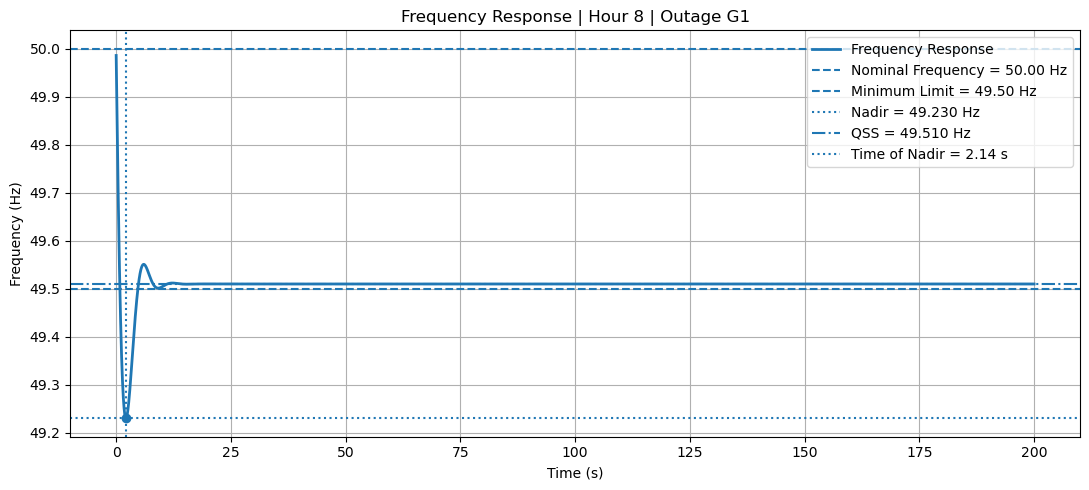

In [306]:
# ============================================================
# 20. PLOT FREQUENCY RESPONSE
# ============================================================

time = freq_result["time"]
freq = freq_result["freq"]

nadir = freq_result["nadir"]
t_nadir = freq_result["t_nadir"]
qss = freq_result["qss"]

plt.figure(figsize=(11, 5))

plt.plot(time, freq, linewidth=2, label="Frequency Response")

plt.axhline(f0, linestyle="--", label=f"Nominal Frequency = {f0:.2f} Hz")
plt.axhline(f_min, linestyle="--", label=f"Minimum Limit = {f_min:.2f} Hz")
plt.axhline(nadir, linestyle=":", label=f"Nadir = {nadir:.3f} Hz")
plt.axhline(qss, linestyle="-.", label=f"QSS = {qss:.3f} Hz")

plt.axvline(t_nadir, linestyle=":", label=f"Time of Nadir = {t_nadir:.2f} s")

plt.scatter(t_nadir, nadir, zorder=5)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Frequency Response | Hour {t_uc} | Outage {freq_result['outage_g']}")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.show()

21-Plot PFR Response

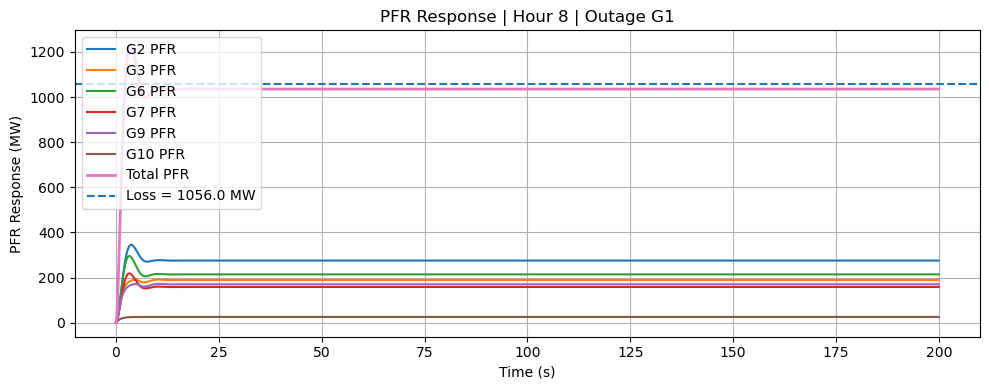

In [307]:
# ============================================================
# 21. PLOT PFR RESPONSE
# ============================================================

plt.figure(figsize=(10, 4))

for g in freq_result["pfr_units"]:
    plt.plot(
        freq_result["time"],
        freq_result["pfr_history"][g],
        label=f"{g} PFR"
    )

plt.plot(
    freq_result["time"],
    freq_result["total_pfr_history"],
    linewidth=2,
    label="Total PFR"
)

plt.axhline(
    freq_result["loss"],
    linestyle="--",
    label=f"Loss = {freq_result['loss']:.1f} MW"
)

plt.xlabel("Time (s)")
plt.ylabel("PFR Response (MW)")
plt.title(f"PFR Response | Hour {t_uc} | Outage {freq_result['outage_g']}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

22-Rekap Frekuensi Semua Jam

In [308]:
# ============================================================
# 22. ALL-HOUR FREQUENCY SUMMARY
# ============================================================
# Bagian ini menjalankan simulasi frekuensi untuk semua jam.
# Hasilnya dipakai untuk melihat jam mana yang paling kritis.

summary = []

for th in list(model.T):
    fr = simulate_frequency_response(
        model=model,
        t_uc=th,
        f0=f0,
        D_frac=D_frac,
        sim_time=sim_time,
        dt=dt
    )

    total_reserve = sum(get_value(model.R[g, th], f"R[{g},{th}]") for g in model.G)
    total_pfr = sum(get_value(model.R_pfr[g, th], f"R[{g},{th}]") for g in model.G)
    net_deficit = fr["loss"] - total_pfr
    pfr_ratio = total_pfr / fr["loss"] if fr["loss"] > 0 else 0

    summary.append([
        th,
        fr["outage_g"],
        round(fr["loss"], 2),
        round(total_reserve, 2),
        round(total_pfr, 2),
        round(net_deficit, 2),
        round(pfr_ratio * 100, 2),
        round(fr["nadir"], 4),
        round(fr["qss"], 4)
    ])

df_freq_summary = pd.DataFrame(summary, columns=[
    "t",
    "Unit Trip",
    "Ploss (MW)",
    "Total Reserve (MW)",
    "Total PFR (MW)",
    "Net Deficit (MW)",
    "PFR Ratio (%)",
    "f_nadir (Hz)",
    "f_steady (Hz)"
])

print("\n========== FREQUENCY ALL-HOUR SUMMARY ==========")
print(df_freq_summary.to_string(index=False))


========== FREQUENCY ALL-HOUR SUMMARY ==========
 t Unit Trip  Ploss (MW)  Total Reserve (MW)  Total PFR (MW)  Net Deficit (MW)  PFR Ratio (%)  f_nadir (Hz)  f_steady (Hz)
 1        G1     1176.00             2659.32         1176.00              0.00         100.00       49.2119        49.5100
 2        G1     1176.00             2711.83         1182.08             -6.08         100.52       49.1888        49.5128
 3        G1     1056.00             2795.80         1198.05           -142.05         113.45       49.2572        49.5203
 4        G1      936.00             2875.62         1119.75           -183.75         119.63       49.3633        49.6158
 5        G1      965.53             2875.62         1176.00           -210.47         121.80       49.3223        49.5630
 6        G1     1056.00             2673.48         1176.00           -120.00         111.36       49.2303        49.5100
 7        G1     1176.00             2611.94         1176.00              0.00         10

23-Grafik Ringkasan Frekuensi

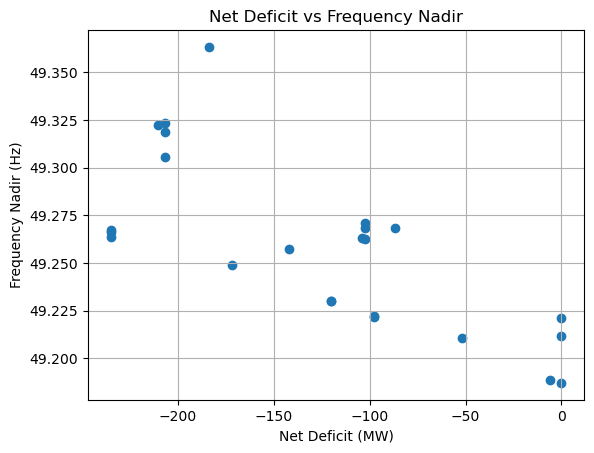

In [309]:
# ============================================================
# 23. FREQUENCY SUMMARY PLOTS
# ============================================================

# Net deficit vs frequency nadir

plt.figure()

plt.scatter(
    df_freq_summary["Net Deficit (MW)"],
    df_freq_summary["f_nadir (Hz)"]
)

plt.xlabel("Net Deficit (MW)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("Net Deficit vs Frequency Nadir")
plt.grid()
plt.show()

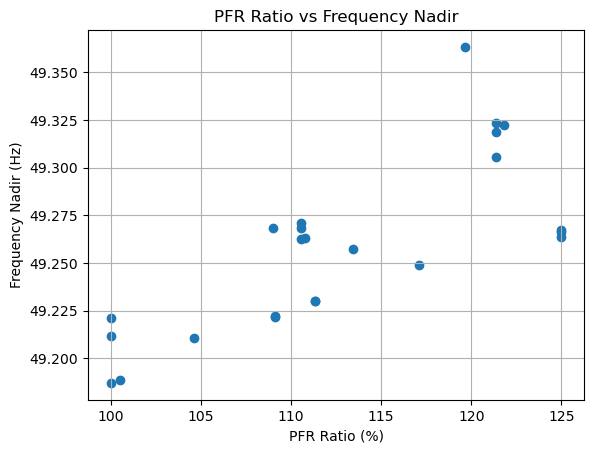

In [310]:
# PFR ratio vs frequency nadir

plt.figure()

plt.scatter(
    df_freq_summary["PFR Ratio (%)"],
    df_freq_summary["f_nadir (Hz)"]
)

plt.xlabel("PFR Ratio (%)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("PFR Ratio vs Frequency Nadir")
plt.grid()
plt.show()

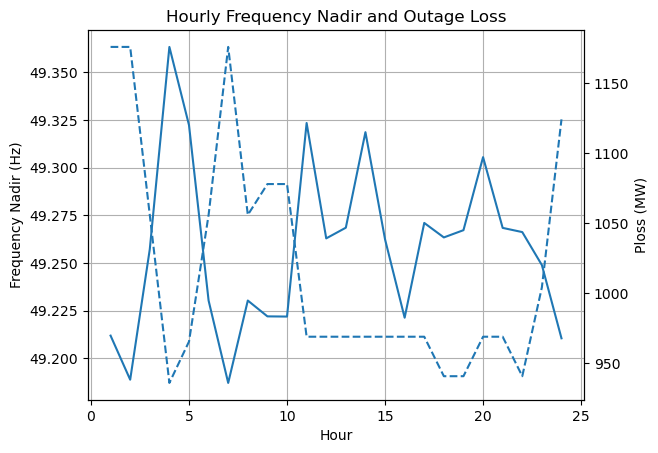

In [311]:
# Trend nadir dan outage loss per jam

fig, ax1 = plt.subplots()

ax1.set_xlabel("Hour")
ax1.set_ylabel("Frequency Nadir (Hz)")
ax1.plot(df_freq_summary["t"], df_freq_summary["f_nadir (Hz)"])
ax1.grid()

ax2 = ax1.twinx()
ax2.set_ylabel("Ploss (MW)")
ax2.plot(df_freq_summary["t"], df_freq_summary["Ploss (MW)"], linestyle="--")

plt.title("Hourly Frequency Nadir and Outage Loss")
plt.show()

24-Plot UC Dispatch dan Status Unit

In [312]:
# ============================================================
# 24. UC VISUALIZATION
# ============================================================

# Mapping nama unit agar legenda lebih mudah dibaca

name_map = {
    "G1": "PLTU 1",
    "G2": "PLTGU 1",
    "G3": "PLTU 2",
    "G4": "PLTG 1",
    "G5": "PLTG 2",
    "G6": "PLTGU 2",
    "G7": "PLTGU 3",
    "G8": "PLTGU 4",
    "G9": "PLTU 3",
    "G10": "PLTU 4"
}

plot_labels = [name_map.get(g, g) for g in model.G]

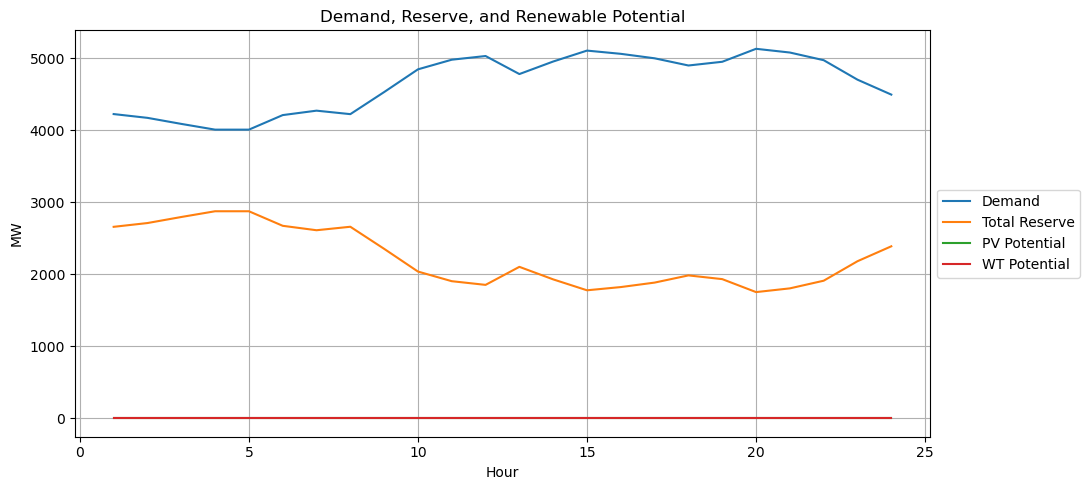

In [313]:
# Demand, reserve, dan renewable potential

hours = list(model.T)

demand = [value(model.Demand[t]) for t in model.T]

total_reserve = [
    sum(get_value(model.R[g, t], f"R[{g},{t}]") for g in model.G)
    for t in model.T
]

pv_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "PV")
    for t in model.T
]

wt_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "WT")
    for t in model.T
]

plt.figure(figsize=(11, 5))

plt.plot(hours, demand, label="Demand")
plt.plot(hours, total_reserve, label="Total Reserve")
plt.plot(hours, pv_potential, label="PV Potential")
plt.plot(hours, wt_potential, label="WT Potential")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Demand, Reserve, and Renewable Potential")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid()
plt.show()

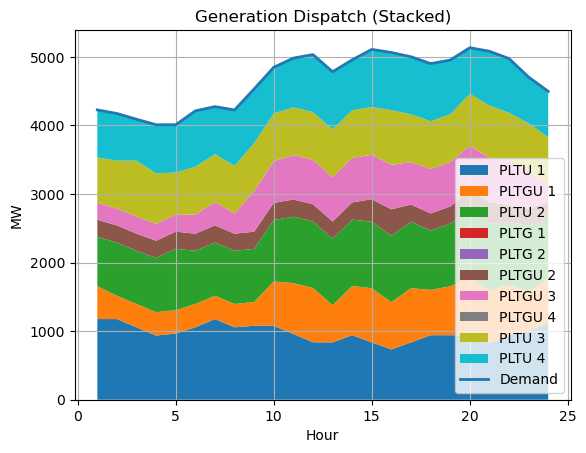

In [314]:
# Dispatch per unit dalam bentuk stacked plot

gen_cols = [f"{g}_P" for g in model.G]

plt.figure()

plt.stackplot(
    df_hourly["Hour"],
    *[df_hourly[col] for col in gen_cols],
    labels=plot_labels
)

plt.plot(
    df_hourly["Hour"],
    df_hourly["Demand"],
    linewidth=2,
    label="Demand"
)

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Generation Dispatch (Stacked)")
plt.legend()
plt.grid()
plt.show()

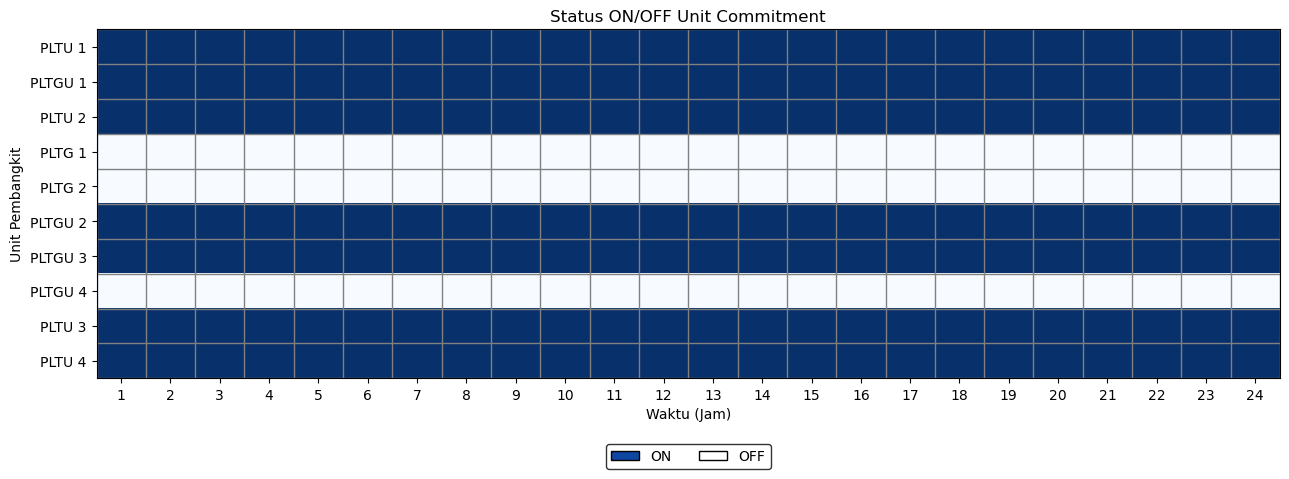

In [315]:
# Status ON/OFF unit
gen_status_matrix = []

for g in model.G:
    gen_status_matrix.append([
        1 if value(model.u[g, t]) > 1e-4 else 0
        for t in model.T
    ])

matrix = np.array(gen_status_matrix)

# Nama unit
unit_labels = [name_map.get(g, g) for g in model.G]

plt.figure(figsize=(13, 5))

# Heatmap
plt.imshow(
    matrix,
    cmap="Blues",
    aspect="auto",
    interpolation="none",
    vmin=0,
    vmax=1
)

# =========================
# AXIS
# =========================
plt.xticks(
    ticks=np.arange(len(list(model.T))),
    labels=list(model.T)
)

plt.yticks(
    ticks=np.arange(len(list(model.G))),
    labels=unit_labels
)

# =========================
# GRID ANTAR KOTAK
# =========================
ax = plt.gca()

# Minor ticks di batas sel
ax.set_xticks(np.arange(-0.5, len(list(model.T)), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(list(model.G)), 1), minor=True)

# Grid hanya untuk minor
ax.grid(
    which="minor",
    color="gray",
    linestyle="-",
    linewidth=1
)

# Hilangkan tampilan minor tick
ax.tick_params(which="minor", bottom=False, left=False)

# =========================
# LABEL & TITLE
# =========================
plt.xlabel("Waktu (Jam)")
plt.ylabel("Unit Pembangkit")
plt.title("Status ON/OFF Unit Commitment")

# =========================
# LEGEND ON/OFF
# =========================
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#0d47a1", edgecolor="black", label="ON"),
    Patch(facecolor="white", edgecolor="black", label="OFF")
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=True,
    edgecolor="black"
)

plt.tight_layout()

plt.show()